In [1]:
# Standard library imports
import sys
import os

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Setup path for src imports
notebooks_dir = os.path.dirname(os.path.abspath('__file__'))
root_dir = os.path.dirname(notebooks_dir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.training import train_random_forest
from src.evaluation import calculate_metrics, feature_importance
from src.visualisation import plot_actual_vs_predicted, plot_error_distribution, plot_residuals, plot_feature_importance


# importing processed datasets for ML

X_train_stress = pd.read_csv("ml_ready_data/X_train_stress.csv")
X_test_stress = pd.read_csv("ml_ready_data/X_test_stress.csv")
y_train_stress = pd.read_csv("ml_ready_data/y_train_stress.csv").squeeze("columns")
y_test_stress = pd.read_csv("ml_ready_data/y_test_stress.csv").squeeze("columns")

X_train_deflection = pd.read_csv("ml_ready_data/X_train_deflection.csv")
X_test_deflection = pd.read_csv("ml_ready_data/X_test_deflection.csv")
y_train_deflection = pd.read_csv("ml_ready_data/y_train_deflection.csv").squeeze("columns")
y_test_deflection = pd.read_csv("ml_ready_data/y_test_deflection.csv").squeeze("columns")

print("Stress model     -> Train:", X_train_stress.shape, " Test:", X_test_stress.shape)
print("Deflection model -> Train:", X_train_deflection.shape, " Test:", X_test_deflection.shape)

Stress model     -> Train: (64, 6)  Test: (17, 6)
Deflection model -> Train: (64, 6)  Test: (17, 6)


# Stress Model

In [2]:
# Model training

stress_model = train_random_forest(X_train_stress, y_train_stress)
print("Model trained.")

Model trained.


In [3]:
# Performance

y_test_mpa = y_test_stress / 1e6
y_pred_stress_pa = stress_model.predict(X_test_stress)
y_pred_mpa = y_pred_stress_pa / 1e6

metrics = calculate_metrics(y_test_stress, y_pred_stress_pa, unit_divisor=1e6)

print(f"MAE:  {metrics['MAE']:.3f} MPa")
print(f"RMSE: {metrics['RMSE']:.3f} MPa")
print(f"R²:   {metrics['R2']:.4f}")

MAE:  1.747 MPa
RMSE: 2.234 MPa
R²:   0.9388


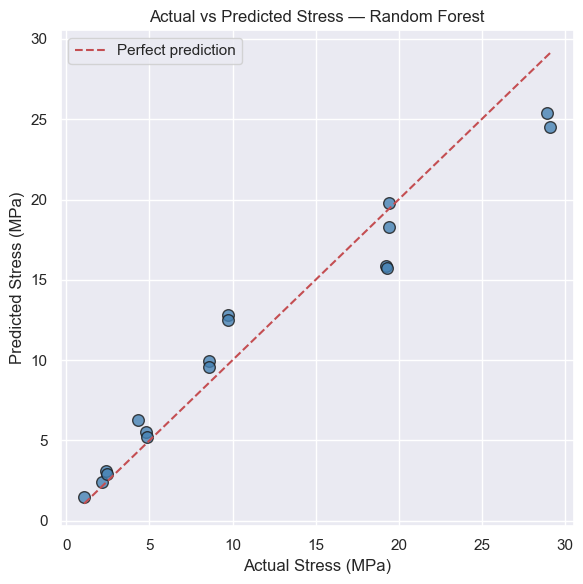

In [4]:
# Actual vs Predicted using src visualization
y_test_mpa = y_test_stress / 1e6
y_pred_mpa = y_pred_stress_pa / 1e6

plot_actual_vs_predicted(
    y_test_mpa, y_pred_mpa,
    xlabel="Actual Stress (MPa)",
    ylabel="Predicted Stress (MPa)",
    title="Actual vs Predicted Stress — Random Forest",
    color="steelblue"
)
plt.show()

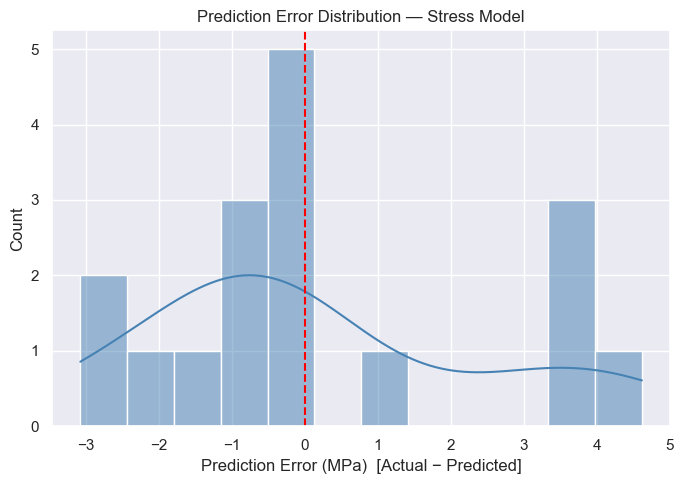

In [5]:
# Prediction error distribution using src visualization
errors = y_test_mpa - y_pred_mpa

plot_error_distribution(
    errors,
    xlabel="Prediction Error (MPa)  [Actual − Predicted]",
    title="Prediction Error Distribution — Stress Model",
    color="steelblue"
)
plt.show()

# Deflection Model

In [6]:
# Deformation model training
deflection_model = train_random_forest(X_train_deflection, y_train_deflection)
print("Model trained.")

Model trained.


In [7]:
# performance

y_pred_defl_m = deflection_model.predict(X_test_deflection)
y_test_mm = y_test_deflection * 1000
y_pred_mm = y_pred_defl_m * 1000

metrics = calculate_metrics(y_test_deflection, y_pred_defl_m, unit_divisor=0.001)

print(f"MAE:  {metrics['MAE']:.3f} mm")
print(f"RMSE: {metrics['RMSE']:.3f} mm")
print(f"R²:   {metrics['R2']:.4f}")

MAE:  11.299 mm
RMSE: 20.172 mm
R²:   0.6962


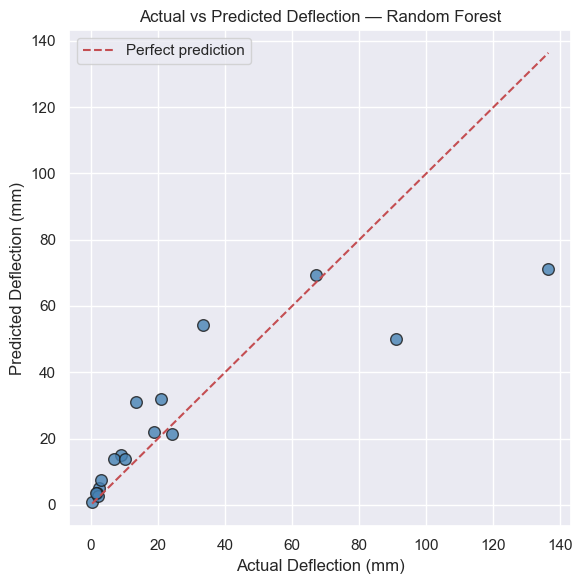

In [8]:
# Actual vs predicted using src visualization
y_test_mm = y_test_deflection * 1000
y_pred_mm = y_pred_defl_m * 1000

plot_actual_vs_predicted(
    y_test_mm, y_pred_mm,
    xlabel="Actual Deflection (mm)",
    ylabel="Predicted Deflection (mm)",
    title="Actual vs Predicted Deflection — Random Forest",
    color="steelblue"
)
plt.show()

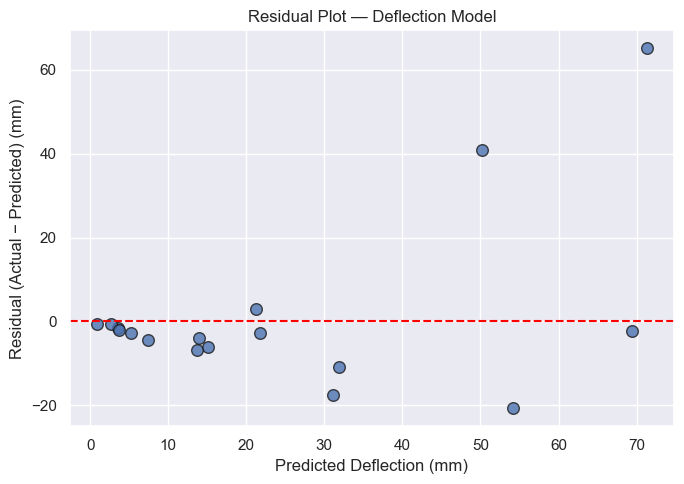

In [9]:
# Residual Plot using src visualization
residuals = y_test_mm - y_pred_mm

plot_residuals(
    y_pred_mm, residuals,
    xlabel="Predicted Deflection (mm)",
    ylabel="Residual (Actual − Predicted) (mm)",
    title="Residual Plot — Deflection Model"
)
plt.show()

# Feature Importance

Feature Importance — Stress Model
Root_Chord_mm            0.381357
Blade_Length_m           0.345577
Applied_Load_Pa          0.250966
Material_Fiberglass      0.008813
Material_Aluminium       0.006814
Material_Carbon fiber    0.006472
dtype: float64


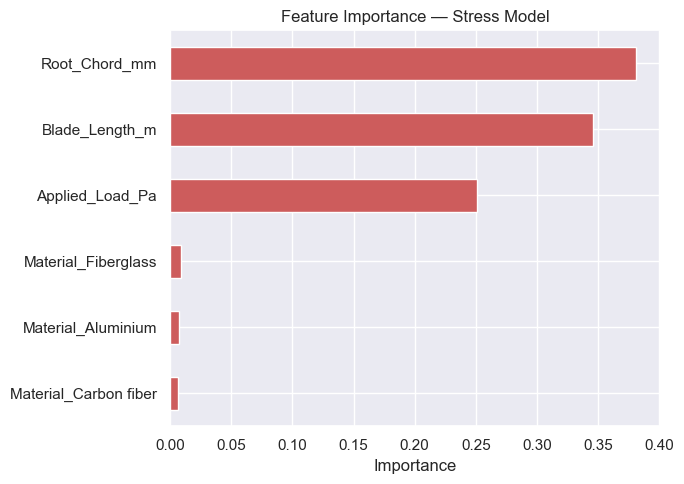

In [10]:
# Stress model feature importance using src functions
stress_importance = feature_importance(stress_model, X_train_stress.columns)

print("Feature Importance — Stress Model")
print(stress_importance)

plot_feature_importance(
    stress_importance,
    title="Feature Importance — Stress Model",
    color="indianred"
)
plt.show()

Feature Importance — Deflection Model
Root_Chord_mm            0.289653
Blade_Length_m           0.274046
Material_Fiberglass      0.264661
Applied_Load_Pa          0.150665
Material_Carbon fiber    0.011040
Material_Aluminium       0.009934
dtype: float64


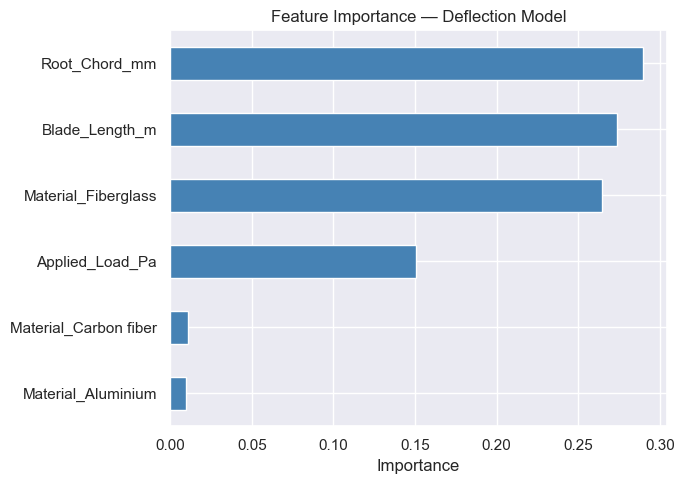

In [11]:
# Deformation model feature importance using src functions
deflection_importance = feature_importance(deflection_model, X_train_deflection.columns)

print("Feature Importance — Deflection Model")
print(deflection_importance)

plot_feature_importance(
    deflection_importance,
    title="Feature Importance — Deflection Model",
    color="steelblue"
)
plt.show()

# Model Optimisation

In [12]:
# Grid search setup

n_trees_opts = [50, 100, 200, 300]
max_depth_opts = [5, 10, 20, None]
min_split_opts = [2, 5, 10]

def run_experiments(X_train, X_test, y_train, y_test, unit_divisor=1.0):
    """unit_divisor converts raw units (Pa or m) to readable units (MPa or mm) for metrics only."""
    records = []
    for nt, md, ms in itertools.product(n_trees_opts, max_depth_opts, min_split_opts):
        model = RandomForestRegressor(n_estimators=nt, max_depth=md, min_samples_split=ms, random_state=42)
        model.fit(X_train, y_train)
        pred_test = model.predict(X_test) / unit_divisor
        pred_train = model.predict(X_train) / unit_divisor
        y_test_u = y_test / unit_divisor
        y_train_u = y_train / unit_divisor
        records.append({
            "n_estimators": nt, "max_depth": md, "min_samples_split": ms,
            "MAE": mean_absolute_error(y_test_u, pred_test),
            "RMSE": np.sqrt(mean_squared_error(y_test_u, pred_test)),
            "R2_test": r2_score(y_test_u, pred_test),
            "R2_train": r2_score(y_train_u, pred_train),
        })
    results_df = pd.DataFrame(records)
    results_df["overfit_gap"] = results_df["R2_train"] - results_df["R2_test"]
    return results_df

In [13]:
# Running for both models
# Stress: y is in Pa, divide by 1e6 for MPa
stress_results = run_experiments(X_train_stress, X_test_stress, y_train_stress, y_test_stress, unit_divisor=1e6)

# Deflection: y is in metres, divide by 0.001 (i.e. multiply by 1000) for mm
deflection_results = run_experiments(X_train_deflection, X_test_deflection, y_train_deflection, y_test_deflection, unit_divisor=0.001)

print("Top 5 configs — Stress (by R² test):")
print(stress_results.sort_values("R2_test", ascending=False).head(5))
print("\nTop 5 configs — Deflection (by R² test):")
print(deflection_results.sort_values("R2_test", ascending=False).head(5))

Top 5 configs — Stress (by R² test):
    n_estimators  max_depth  min_samples_split       MAE      RMSE   R2_test  \
0             50        5.0                  2  1.615171  2.159321  0.942827   
12           100        5.0                  2  1.752571  2.184249  0.941499   
45           300        NaN                  2  1.692793  2.200655  0.940617   
42           300       20.0                  2  1.692793  2.200655  0.940617   
39           300       10.0                  2  1.692793  2.200655  0.940617   

    R2_train  overfit_gap  
0   0.988333     0.045506  
12  0.989771     0.048272  
45  0.992523     0.051906  
42  0.992523     0.051906  
39  0.992523     0.051906  

Top 5 configs — Deflection (by R² test):
    n_estimators  max_depth  min_samples_split        MAE       RMSE  \
15           100       10.0                  2  11.299385  20.171816   
18           100       20.0                  2  11.299385  20.171816   
21           100        NaN                  2  11.29938

In [14]:
# Baseline Comparison
def show_baseline(results_df, label):
    baseline = results_df[(results_df.n_estimators == 100) &
                           (results_df.max_depth.isna()) &
                           (results_df.min_samples_split == 2)]
    print(f"--- {label} baseline ---")
    print(baseline)

show_baseline(stress_results, "Stress")
show_baseline(deflection_results, "Deflection")

--- Stress baseline ---
    n_estimators  max_depth  min_samples_split       MAE      RMSE   R2_test  \
21           100        NaN                  2  1.747226  2.233932  0.938808   

    R2_train  overfit_gap  
21  0.991436     0.052628  
--- Deflection baseline ---
    n_estimators  max_depth  min_samples_split        MAE       RMSE  \
21           100        NaN                  2  11.299385  20.171816   

     R2_test  R2_train  overfit_gap  
21  0.696186  0.967013     0.270828  
